In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('train (2).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [6]:
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
928,TA,TA,236500
121,NaN,TA,100000
407,NaN,TA,177000
1054,Gd,TA,255000
563,Gd,TA,185000


In [7]:
df.shape

(1460, 3)

In [8]:
df.isnull().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

<Axes: xlabel='GarageQual'>

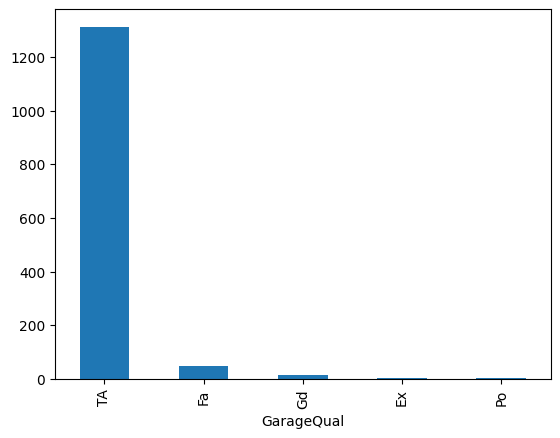

In [10]:
df['GarageQual'].value_counts().plot.bar()

In [11]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

<Axes: ylabel='Density'>

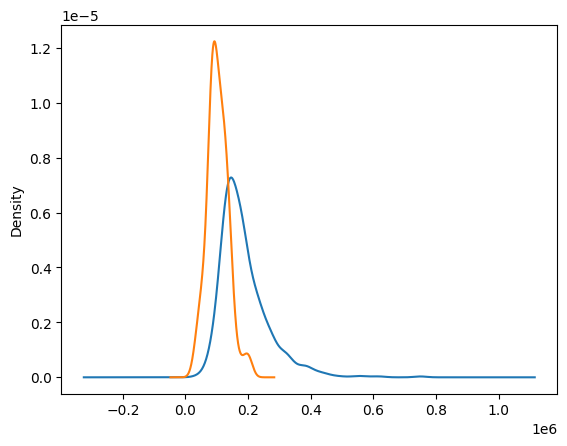

In [14]:
fig = plt.figure()
ax = fig.add_subplot()

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax)

In [16]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [17]:
df['GarageQual'].fillna('TA',inplace=True)

C:\Users\LENOVO THINKBOOK\AppData\Local\Temp\ipykernel_6924\584385255.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['GarageQual'].fillna('TA',inplace=True)


0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: str

<Axes: xlabel='GarageQual'>

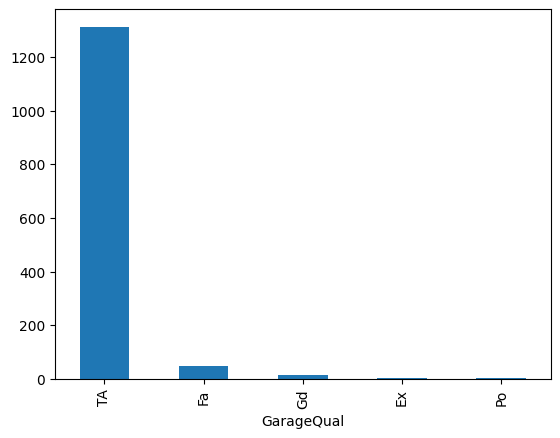

In [18]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

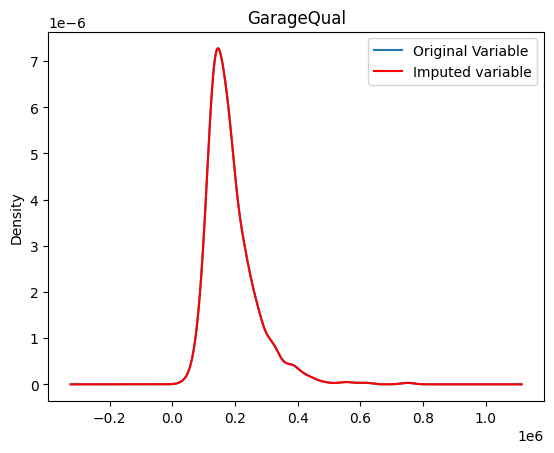

In [24]:
fig = plt.figure()
ax = fig.add_subplot()


temp.plot(kind='kde',ax=ax)


df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')


<Axes: xlabel='FireplaceQu'>

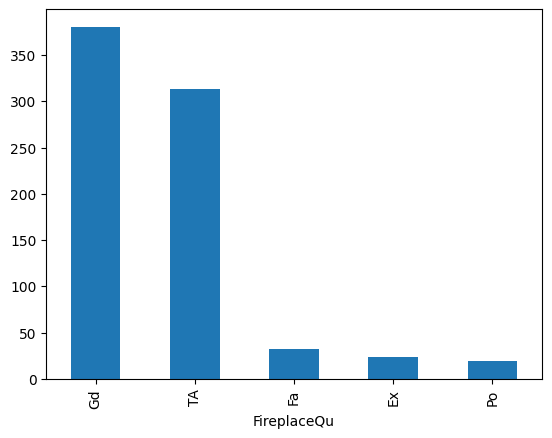

In [25]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [26]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: str

Text(0.5, 1.0, 'FireplaceQu')

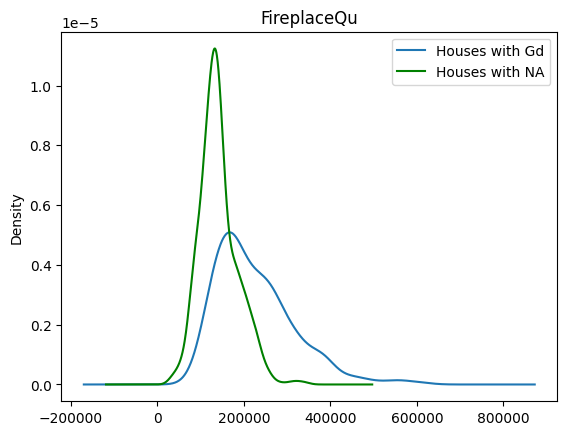

In [30]:
fig = plt.figure()
ax = fig.add_subplot()


df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)


df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [31]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [32]:
df['FireplaceQu'].fillna('Gd', inplace=True)

C:\Users\LENOVO THINKBOOK\AppData\Local\Temp\ipykernel_6924\3912738894.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['FireplaceQu'].fillna('Gd', inplace=True)


0       Gd
1       TA
2       TA
3       Gd
4       TA
        ..
1455    TA
1456    TA
1457    Gd
1458    Gd
1459    Gd
Name: FireplaceQu, Length: 1460, dtype: str

<Axes: xlabel='FireplaceQu'>

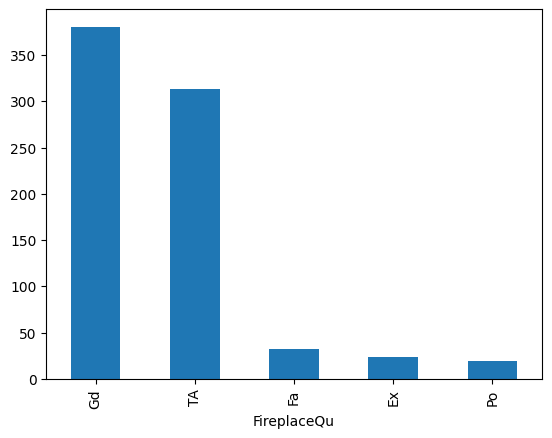

In [33]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

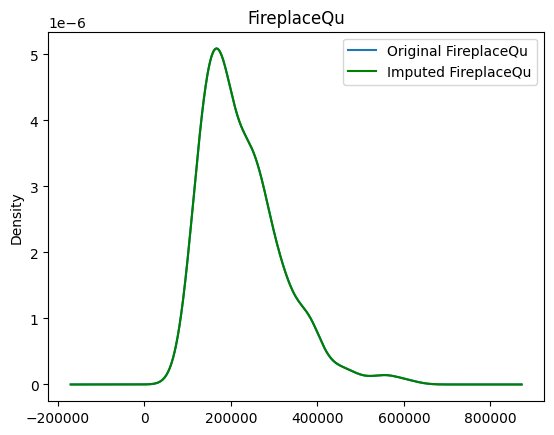

In [39]:
fig = plt.figure()
ax = fig.add_subplot()

temp.plot(kind='kde', ax=ax)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original FireplaceQu', 'Imputed FireplaceQu']

ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [43]:
from sklearn.model_selection import train_test_split

In [46]:
x = df.drop(columns=['SalePrice'])
y = df['SalePrice']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

In [49]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_train)

In [50]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)